# D7 on D6c-v2: Stack-5 + Cosine LR + Dropout under Label Noise
## Benchmarking Noise-Robust Training Strategies for Liver Tumor Segmentation on LiTS


## 1. Noise Configuration

In [ ]:
NOISE_TYPE = 'combined'    # 'missing' | 'jitter' | 'combined' | None
NOISE_RATE = 0.50

STRATEGY     = 'D6cV2'
NOISE_SEED   = 2026          # KEEP CONSTANT across all D7 strategies
RESULTS_FILE = f'results_d7_{STRATEGY}.json'

config_tag = (
    f'{STRATEGY}__clean' if NOISE_TYPE is None
    else f'{STRATEGY}__{NOISE_TYPE}_r{int(round(NOISE_RATE*100)):02d}'
)
print(f'Config: {config_tag}')


Config: D6cV2__combined_r50


## 2. Imports

In [2]:
import os, sys, json, time, random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

sys.path.insert(0, '.')
from lits_core import (get_device, load_lits_paths, make_split,
                       LiTS25DDataset, UNet2D, combined_loss,
                       compute_dice_per_class)

DEVICE = get_device()
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f'Device: {DEVICE} | PyTorch: {torch.__version__}')


Device: cuda | PyTorch: 2.11.0+cu128


## 3. Configuration (matches D6c-v2)

In [ ]:
DATA_DIR     = '/home/adnan/aeman_dl/archive-2'
OUT_DIR      = './out_d7_d6cv2'

IMG_SIZE     = 128
BATCH_SIZE   = 16
NUM_EPOCHS   = 18                # cosine needs full schedule (D6c-v2 default)
LR           = 1e-4         
WEIGHT_DECAY = 1e-5
ETA_MIN      = 1e-7              # cosine end LR
STACK_SIZE   = 5
DROPOUT_P    = 0.3

os.makedirs(OUT_DIR, exist_ok=True)
print(f'Stack={STACK_SIZE}  Dropout={DROPOUT_P}  '
      f'Cosine LR {LR}->{ETA_MIN} over {NUM_EPOCHS} epochs')


Stack=5  Dropout=0.3  Cosine LR 0.0001->1e-07 over 18 epochs


## 4. Load + Split

In [ ]:
volume_paths, seg_paths = load_lits_paths(DATA_DIR)
train_v, train_s, val_v, val_s, test_v, test_s = make_split(
    volume_paths, seg_paths, seed=SEED)


Found 51 matched volume-segmentation pairs
Split — Train: 35 | Val: 8 | Test: 8


## 5. Datasets — Train Noisy, Val Clean

In [5]:
print('Building train dataset...')
train_dataset = LiTS25DDataset(
    train_v, train_s, img_size=IMG_SIZE, stack_size=STACK_SIZE,
    augment=False,
    noise_type=NOISE_TYPE,
    noise_rate=NOISE_RATE if NOISE_TYPE else 0.0,
    noise_seed=NOISE_SEED,
)

print('\nBuilding val dataset (clean)...')
val_dataset = LiTS25DDataset(
    val_v, val_s, img_size=IMG_SIZE, stack_size=STACK_SIZE,
    augment=False, noise_type=None, noise_rate=0.0,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)
print(f'\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)}')


Building train dataset...
Dataset: 4614 slices | stack=5 | augment=False (medium) | noise=combined@50% (2265 slices)

Building val dataset (clean)...
Dataset: 1116 slices | stack=5 | augment=False (medium) | noise=None@0% (0 slices)

Train batches: 289 | Val batches: 70


## 6. Sanity Check — Visualize Noisy Slices

Noisy slices: 2265 / 4614
Dataset: 4614 slices | stack=5 | augment=False (medium) | noise=None@0% (0 slices)


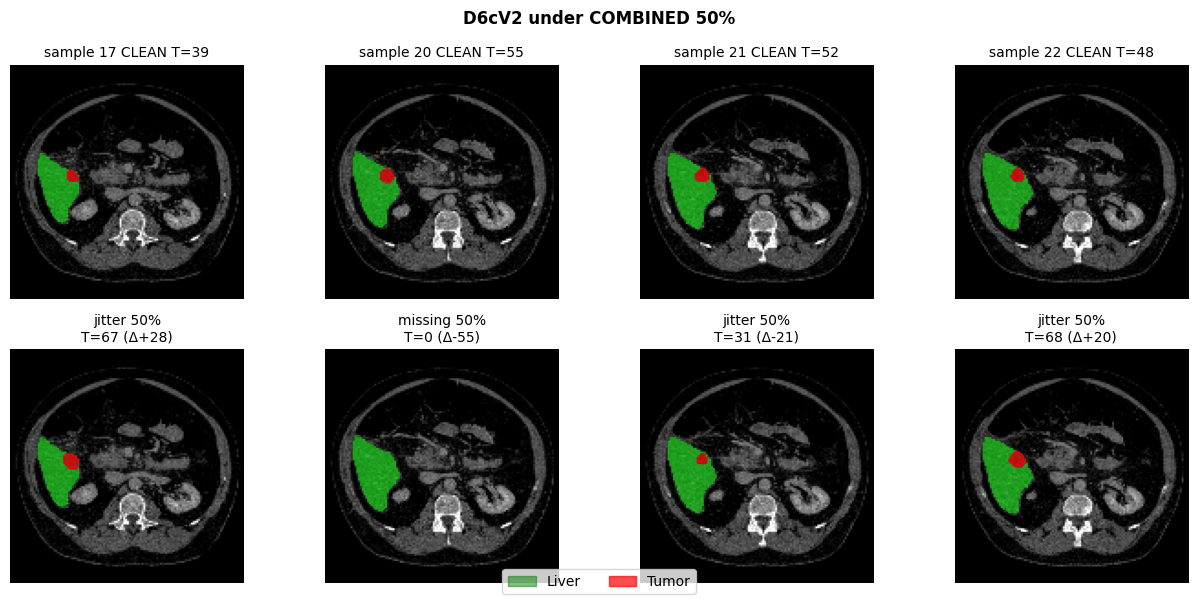

In [6]:
if NOISE_TYPE is None:
    print('Clean run.')
else:
    noisy_idxs = np.where(train_dataset._noisy_mask)[0]
    print(f'Noisy slices: {len(noisy_idxs)} / {len(train_dataset)}')

    clean_dataset = LiTS25DDataset(
        train_v, train_s, img_size=IMG_SIZE, stack_size=STACK_SIZE,
        augment=False, noise_type=None, noise_rate=0.0)

    show = []
    for i in noisy_idxs:
        _, m = clean_dataset[int(i)]
        if (m == 2).sum().item() > 30:
            show.append(int(i))
        if len(show) >= 4:
            break

    if show:
        center = STACK_SIZE // 2
        fig, axes = plt.subplots(2, len(show), figsize=(3.2 * len(show), 6))
        if len(show) == 1: axes = axes[:, None]
        for col, i in enumerate(show):
            ct, m_clean = clean_dataset[i]
            _, m_noisy = train_dataset[i]
            ct_img = ct[center].numpy()
            mc, mn = m_clean.numpy(), m_noisy.numpy()
            for row, (m, label) in enumerate([(mc, 'CLEAN'), (mn, 'NOISY')]):
                ov = np.zeros((*ct_img.shape, 4))
                ov[m == 1] = [0, 1, 0, 0.5]
                ov[m == 2] = [1, 0, 0, 0.7]
                axes[row, col].imshow(ct_img.T, cmap='gray', origin='lower')
                axes[row, col].imshow(ov.transpose(1, 0, 2), origin='lower')
                t_px = (m == 2).sum()
                if row == 0:
                    title = f'sample {i} CLEAN T={t_px}'
                else:
                    delta = int(t_px - (mc == 2).sum())
                    kind = train_dataset._noisy_kinds[i] if NOISE_TYPE == 'combined' else NOISE_TYPE
                    title = f'{kind} {NOISE_RATE:.0%}\nT={t_px} (Δ{delta:+})'
                axes[row, col].set_title(title, fontsize=10)
                axes[row, col].axis('off')

        green = mpatches.Patch(color='green', alpha=0.5, label='Liver')
        red   = mpatches.Patch(color='red',   alpha=0.7, label='Tumor')
        fig.legend(handles=[green, red], loc='lower center', ncol=2)
        plt.suptitle(f'{STRATEGY} under {NOISE_TYPE.upper()} {NOISE_RATE:.0%}',
                     fontweight='bold')
        plt.tight_layout(); plt.show()


## 7. Build Model — Stack-5 U-Net + Bottleneck Dropout

In [ ]:
model = UNet2D(in_channels=STACK_SIZE, num_classes=3,
               base_features=64, use_attention=False).to(DEVICE)

original_bottleneck = model.bottleneck
model.bottleneck = nn.Sequential(
    original_bottleneck,
    nn.Dropout2d(p=DROPOUT_P),
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: in_channels={STACK_SIZE}, dropout={DROPOUT_P}, params={n_params:,}')


Model: in_channels=5, dropout=0.3, params=31,038,915


## 8. Training — Custom Loop with Cosine LR

Using a custom loop (not `lits_core.train_model`) because D6c-v2 uses `CosineAnnealingLR`, while `lits_core.train_model` is hardcoded to `ReduceLROnPlateau`.


In [8]:
torch.manual_seed(SEED)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=ETA_MIN)

history = {k: [] for k in
           ['train_loss', 'val_loss', 'val_liver_dice', 'val_tumor_dice',
            'epoch_mins', 'lr']}
best_tumor_dice = 0.0
best_state = None

print('=' * 78)
print(f'TRAINING: {config_tag}')
print(f'  {NUM_EPOCHS} epochs | cosine {LR}->{ETA_MIN} | dropout={DROPOUT_P}')
print('=' * 78)

run_start = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    current_lr = optimizer.param_groups[0]['lr']

    model.train()
    train_losses = []
    for bi, (ct, seg) in enumerate(train_loader):
        ct, seg = ct.to(DEVICE), seg.to(DEVICE)
        optimizer.zero_grad()
        loss = combined_loss(model(ct), seg)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        if (bi + 1) % 100 == 0:
            print(f'  ep {epoch:02d} batch {bi+1}/{len(train_loader)} loss={loss.item():.4f}')

    model.eval()
    val_losses, livers, tumors = [], [], []
    with torch.no_grad():
        for ct, seg in val_loader:
            ct, seg = ct.to(DEVICE), seg.to(DEVICE)
            preds = model(ct)
            val_losses.append(combined_loss(preds, seg).item())
            d = compute_dice_per_class(preds, seg)
            livers.append(d[1]); tumors.append(d[2])

    m_train = float(np.mean(train_losses))
    m_val   = float(np.mean(val_losses))
    m_liver = float(np.mean(livers))
    m_tumor = float(np.mean(tumors))
    em = (time.time() - t0) / 60

    for k, v in [('train_loss', m_train), ('val_loss', m_val),
                 ('val_liver_dice', m_liver), ('val_tumor_dice', m_tumor),
                 ('epoch_mins', em), ('lr', current_lr)]:
        history[k].append(v)

    scheduler.step()

    flag = ''
    if m_tumor > best_tumor_dice:
        best_tumor_dice = m_tumor
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        flag = ' *** BEST'

    print(f'Ep {epoch:02d}/{NUM_EPOCHS} | {em:4.1f}min | LR={current_lr:.2e} | '
          f'Train: {m_train:.4f} | Val: {m_val:.4f} | '
          f'Liver: {m_liver:.4f} | Tumor: {m_tumor:.4f}{flag}')

run_mins = (time.time() - run_start) / 60

best_idx = int(np.argmax(history['val_tumor_dice']))
best_tumor_dice = float(history['val_tumor_dice'][best_idx])
best_liver_at_best_tumor = float(history['val_liver_dice'][best_idx])
best_epoch = best_idx + 1

ckpt = os.path.join(OUT_DIR, f'best_{config_tag}.pth')
torch.save(best_state, ckpt)
print(f'\nBest: tumor={best_tumor_dice:.4f} liver={best_liver_at_best_tumor:.4f} '
      f'@ epoch {best_epoch}')
print(f'Total time: {run_mins:.1f} min  |  Checkpoint: {ckpt}')


TRAINING: D6cV2__combined_r50
  18 epochs | cosine 0.0001->1e-07 | dropout=0.3
  ep 01 batch 100/289 loss=0.9581
  ep 01 batch 200/289 loss=0.8063
Ep 01/18 |  2.7min | LR=1.00e-04 | Train: 0.9288 | Val: 0.7290 | Liver: 0.8483 | Tumor: 0.5286 *** BEST
  ep 02 batch 100/289 loss=0.6108
  ep 02 batch 200/289 loss=0.5231
Ep 02/18 |  1.7min | LR=9.92e-05 | Train: 0.5825 | Val: 0.5658 | Liver: 0.8763 | Tumor: 0.2687
  ep 03 batch 100/289 loss=0.4251
  ep 03 batch 200/289 loss=0.4454
Ep 03/18 |  1.7min | LR=9.70e-05 | Train: 0.4428 | Val: 0.4908 | Liver: 0.8638 | Tumor: 0.5259
  ep 04 batch 100/289 loss=0.2732
  ep 04 batch 200/289 loss=0.3551
Ep 04/18 |  1.7min | LR=9.33e-05 | Train: 0.3682 | Val: 0.4420 | Liver: 0.8854 | Tumor: 0.3206
  ep 05 batch 100/289 loss=0.2844
  ep 05 batch 200/289 loss=0.1965
Ep 05/18 |  1.7min | LR=8.83e-05 | Train: 0.3038 | Val: 0.4408 | Liver: 0.8527 | Tumor: 0.1951
  ep 06 batch 100/289 loss=0.2177
  ep 06 batch 200/289 loss=0.3642
Ep 06/18 |  2.0min | LR=8.22e

## 9. Save Result to JSON

In [9]:
results_path = Path(RESULTS_FILE)
results = json.load(results_path.open()) if results_path.exists() else {}

results[config_tag] = {
    'strategy':    STRATEGY,
    'noise_type':  NOISE_TYPE,
    'noise_rate':  NOISE_RATE if NOISE_TYPE else 0.0,
    'noise_seed':  NOISE_SEED,
    'liver_dice':  best_liver_at_best_tumor,
    'tumor_dice':  best_tumor_dice,
    'best_epoch':  best_epoch,
    'history':     history,
    'num_epochs':  NUM_EPOCHS,
    'run_minutes': float(run_mins),
    'stack_size':  STACK_SIZE,
    'dropout':     DROPOUT_P,
    'scheduler':   'cosine',
}

results_path.write_text(json.dumps(results, indent=2, default=str))
print(f'Saved {config_tag} to {RESULTS_FILE}')
print(f'\nAll entries:')
for k, v in sorted(results.items()):
    print(f'  {k:30s}  liver={v["liver_dice"]:.4f}  tumor={v["tumor_dice"]:.4f}')


Saved D6cV2__combined_r50 to results_d7_D6cV2.json

All entries:
  D6cV2__combined_r50             liver=0.8923  tumor=0.5528
